In [6]:
import json

with open("./baseline_score.jsonl", "r", encoding="utf-8") as f:

    for i, line in enumerate(f, start=1):

        line = line.strip()

        if not line:
            print(f"Empty line at {i}")
            continue

        try:
            json.loads(line)

        except Exception as e:
            print(f"Error on line {i}")
            print(e)
            print(line[:300])
            break

In [8]:
import json
import pandas as pd


with open("./baseline_score.jsonl", "r", encoding="utf-8") as f:
    print(repr(f.readline()))

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows


baseline = load_jsonl("./baseline_score.jsonl")
ragas = load_jsonl("./ragas_score.jsonl")
selfcheck = load_jsonl("./selfcheck_score.jsonl")
similarity = load_jsonl("./similarity_score.jsonl")

merged = {}

# -------------------
# Baseline
# -------------------

for x in baseline:
    merged[x["id"]] = {
        "id": x["id"],
        "question": x["question"],
        "difficulty": x["difficulty"],
        "question_type": x["question_type"],
        "source_doc": x["source_doc"],
        "baseline": x["hallucination"]
    }

# -------------------
# RAGAS
# -------------------

for x in ragas:

    idx = x["original_id"]

    if idx not in merged:
        merged[idx] = {}

    merged[idx]["ragas"] = float(x["faithfulness"])

# -------------------
# SelfCheck
# -------------------

for x in selfcheck:

    idx = x["id"]

    if idx not in merged:
        merged[idx] = {}

    merged[idx]["selfcheck"] = x["selfcheck_hallucination"]

# -------------------
# Similarity
# -------------------

for x in similarity:

    idx = x["id"]

    if idx not in merged:
        merged[idx] = {}

    merged[idx]["similarity"] = x["retrail_similarity"]

df = pd.DataFrame(merged.values())

df.to_csv("merged_results.csv", index=False)

print(df.head())

'{"id": "741920fe-c7d4-4e38-a239-207741b9e271", "question": "Which document specifies the details of HTTP semantics?", "answer": "RFC 9110 HTTP Semantics June 2022.", "evidence": "RFC 9110 HTTP Semantics June 2022", "question_type": "identifier", "difficulty": "easy", "chunk_id": "docs/rfc9110.pdf_chunk_502", "source_doc": "docs/rfc9110.pdf", "rag_answer": "The document that specifies the details of HTTP semantics is RFC 9110 HTTP Semantics June 2022, as authored by Fielding, et al. This can be inferred from references within the provided context where it is repeatedly cited as the source for information on HTTP semantics.", "hallucination": 0}\n'
                                     id  \
0  741920fe-c7d4-4e38-a239-207741b9e271   
1  2877f7fb-7d11-4db3-9e45-46c7be5fc563   
2  2f1092b2-b16f-4015-b32a-e4617f682f29   
3  a759b7ef-6bb5-4fc5-b569-f06fff66c33a   
4  ff8371e1-f554-4444-85e5-c25d1ce8a6aa   

                                            question difficulty question_type  \
0  W

In [10]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 29.8 MB/s  0:00:00 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 27.1 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


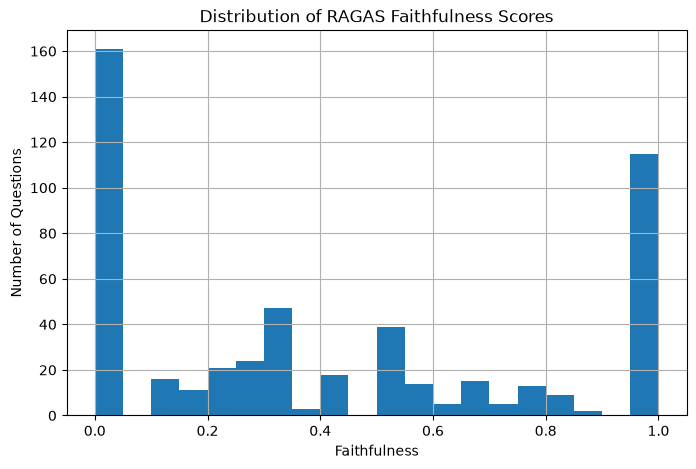

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("merged_results.csv")

plt.figure(figsize=(8,5))

plt.hist(df["ragas"], bins=20)

plt.title("Distribution of RAGAS Faithfulness Scores")

plt.xlabel("Faithfulness")

plt.ylabel("Number of Questions")

plt.grid(True)

plt.show()

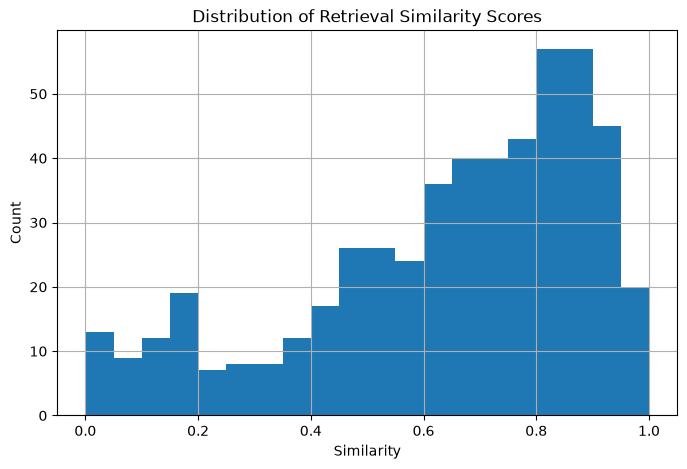

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["similarity"], bins=20)

plt.title("Distribution of Retrieval Similarity Scores")

plt.xlabel("Similarity")

plt.ylabel("Count")

plt.grid(True)

plt.show()

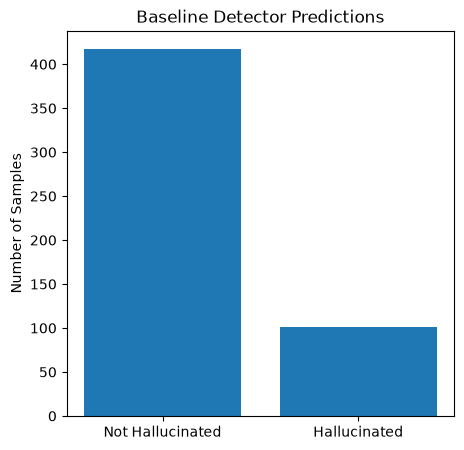

In [15]:
counts = df["baseline"].value_counts()

plt.figure(figsize=(5,5))

plt.bar(
    ["Not Hallucinated","Hallucinated"],
    [counts.get(0,0),counts.get(1,0)]
)

plt.title("Baseline Detector Predictions")

plt.ylabel("Number of Samples")

plt.show()

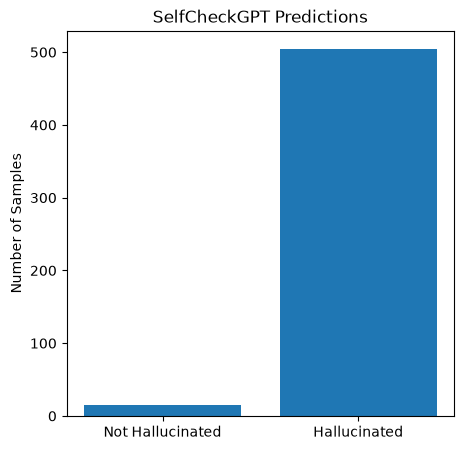

In [16]:
counts = df["selfcheck"].value_counts()

plt.figure(figsize=(5,5))

plt.bar(
    ["Not Hallucinated","Hallucinated"],
    [counts.get(0,0),counts.get(1,0)]
)

plt.title("SelfCheckGPT Predictions")

plt.ylabel("Number of Samples")

plt.show()

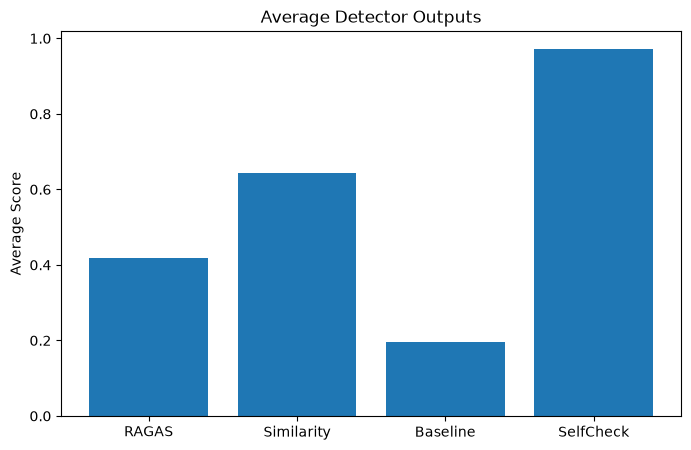

In [17]:
means = {

    "RAGAS":df["ragas"].mean(),

    "Similarity":df["similarity"].mean(),

    "Baseline":df["baseline"].mean(),

    "SelfCheck":df["selfcheck"].mean()

}

plt.figure(figsize=(8,5))

plt.bar(means.keys(),means.values())

plt.title("Average Detector Outputs")

plt.ylabel("Average Score")

plt.show()

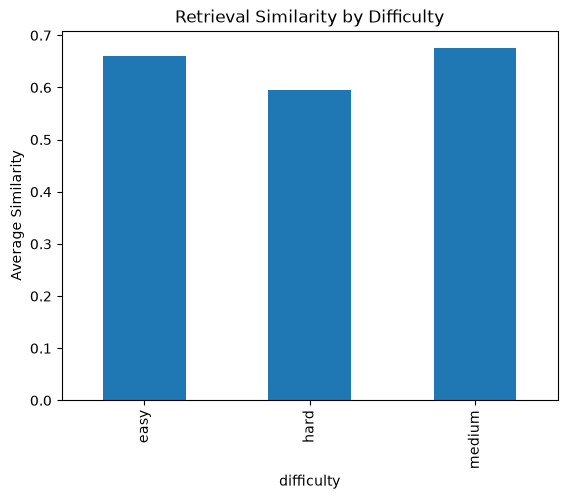

In [18]:
difficulty = df.groupby("difficulty")["similarity"].mean()

difficulty.plot(kind="bar")

plt.ylabel("Average Similarity")

plt.title("Retrieval Similarity by Difficulty")

plt.show()

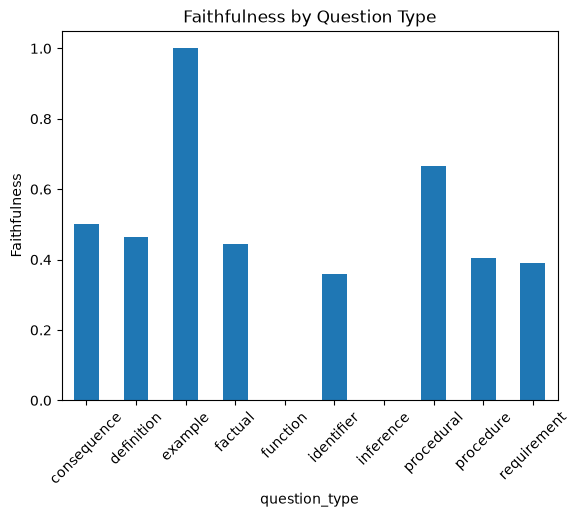

In [19]:
question = df.groupby("question_type")["ragas"].mean()

question.plot(kind="bar")

plt.xticks(rotation=45)

plt.ylabel("Faithfulness")

plt.title("Faithfulness by Question Type")

plt.show()

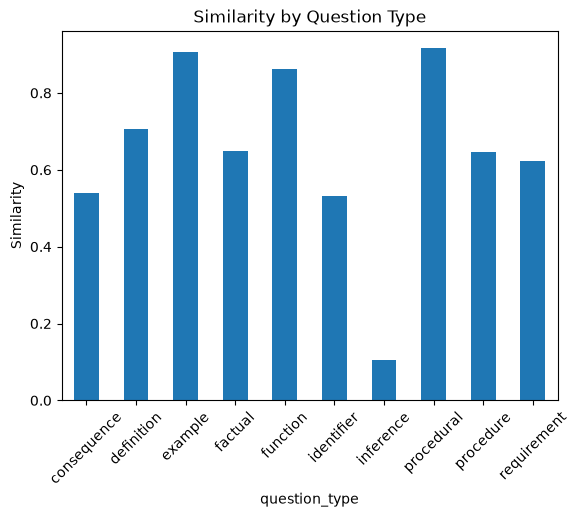

In [20]:
question = df.groupby("question_type")["similarity"].mean()

question.plot(kind="bar")

plt.xticks(rotation=45)

plt.ylabel("Similarity")

plt.title("Similarity by Question Type")

plt.show()

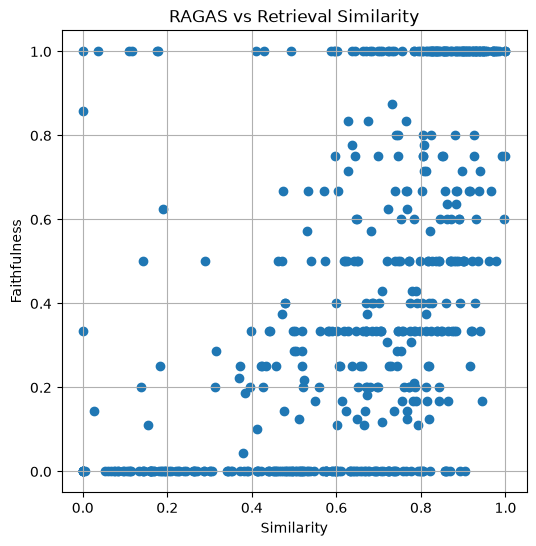

In [21]:
plt.figure(figsize=(6,6))

plt.scatter(df["similarity"],df["ragas"])

plt.xlabel("Similarity")

plt.ylabel("Faithfulness")

plt.title("RAGAS vs Retrieval Similarity")

plt.grid(True)

plt.show()